# Python Itertools Mastery
## Complete Guide with Theory and Practical Examples

The `itertools` module provides a collection of fast, memory-efficient tools for working with iterators. These functions create iterator building blocks that can be combined to create sophisticated data pipelines.

In [45]:
# Import all itertools functions we'll use
import itertools
import operator
import sys
from itertools import *  # For convenience in examples

# For visualization and timing
import time
import pandas as pd
from IPython.display import display, HTML

## Table of Contents
1. **Infinite Iterators**
   - count()
   - cycle()
   - repeat()
   
2. **Finite Iterators**
   - accumulate()
   - chain()
   - compress()
   - dropwhile()
   - filterfalse()
   - groupby()
   - islice()
   - pairwise()
   - starmap()
   - takewhile()
   - tee()
   - zip_longest()
   
3. **Combinatoric Iterators**
   - product()
   - permutations()
   - combinations()
   - combinations_with_replacement()
   
4. **Practical Applications**
   - Data processing pipelines
   - Sliding window operations
   - Cartesian products in analytics
   - Memory-efficient data streaming

## 1. Infinite Iterators

These iterators generate sequences indefinitely. Use them with caution and always have a stopping condition!

### count(start=0, step=1)
Generates consecutive numbers indefinitely.

In [5]:
# Basic count example
counter = count(10, 2.5)
print("First 5 numbers from count(10, 2.5):")
for i in range(5):
    print(f"  {next(counter)}")

# Practical: enumerate with custom start
fruits = ['apple', 'banana', 'cherry', 'date']
for i, fruit in zip(count(1), fruits):
    print(f"{i}. {fruit}")

First 5 numbers from count(10, 2.5):
  10
  12.5
  15.0
  17.5
  20.0
1. apple
2. banana
3. cherry
4. date


In [6]:
for i in counter:
    print(i)
    if i > 10:
        break

22.5


### cycle(iterable)
Cycles through an iterable indefinitely.

In [7]:
# Traffic light simulation
lights = cycle(['🔴 Red', '🟡 Yellow', '🟢 Green'])
print("Traffic light sequence (first 7 states):")
for i, light in enumerate(lights):
    if i >= 7:
        break
    print(f"  {i+1}: {light}")

# Round-robin task scheduling
tasks = ['Process A', 'Process B', 'Process C']
task_cycle = cycle(tasks)
print("\nRound-robin task execution:")
for i, task in enumerate(task_cycle):
    if i >= 10:
        break
    print(f"  Cycle {i+1}: {task}")

Traffic light sequence (first 7 states):
  1: 🔴 Red
  2: 🟡 Yellow
  3: 🟢 Green
  4: 🔴 Red
  5: 🟡 Yellow
  6: 🟢 Green
  7: 🔴 Red

Round-robin task execution:
  Cycle 1: Process A
  Cycle 2: Process B
  Cycle 3: Process C
  Cycle 4: Process A
  Cycle 5: Process B
  Cycle 6: Process C
  Cycle 7: Process A
  Cycle 8: Process B
  Cycle 9: Process C
  Cycle 10: Process A


### repeat(object, times=None)
Repeats an object indefinitely or a specified number of times.

In [8]:
# Basic repetition
print("Repeat 'Hello' 5 times:")
for item in repeat('Hello', 5):
    print(f"  {item}")

# Practical: create constant values in list comprehension
squares = [x**2 for x in range(5)]
constant_pairs = list(zip(squares, repeat(100)))
print("\nPair squares with constant 100:")
print(f"  {constant_pairs}")

# Map with constant function argument
numbers = [1, 2, 3, 4, 5]
result = list(map(pow, numbers, repeat(3)))
print("\nNumbers raised to power 3:")
print(f"  {result}")

Repeat 'Hello' 5 times:
  Hello
  Hello
  Hello
  Hello
  Hello

Pair squares with constant 100:
  [(0, 100), (1, 100), (4, 100), (9, 100), (16, 100)]

Numbers raised to power 3:
  [1, 8, 27, 64, 125]


## 2. Finite Iterators

These iterators work with finite sequences and produce finite outputs.

### accumulate(iterable, func=operator.add)
Returns accumulated sums or results of binary function.

In [9]:
# Running total
numbers = [10, 20, 30, 40, 50]
running_total = list(accumulate(numbers))
print("Running total:", running_total)

# Running multiplication
running_product = list(accumulate(numbers, operator.mul))
print("Running product:", running_product)

# Running maximum
running_max = list(accumulate(numbers, max))
print("Running maximum:", running_max)

# Financial: compound interest
interest_rates = [1.05, 1.04, 1.06, 1.03]  # Annual growth factors
initial = 1000
balances = list(accumulate(interest_rates, lambda bal, rate: bal * rate, initial=initial))
print("\nAccount balances after each year:")
for year, balance in enumerate(balances, 1):
    print(f"  Year {year}: ${balance:.2f}")

Running total: [10, 30, 60, 100, 150]
Running product: [10, 200, 6000, 240000, 12000000]
Running maximum: [10, 20, 30, 40, 50]

Account balances after each year:
  Year 1: $1000.00
  Year 2: $1050.00
  Year 3: $1092.00
  Year 4: $1157.52
  Year 5: $1192.25


# Cviceni

In [20]:
print(list(accumulate(numbers, lambda x,y: x+y+2, initial = 500)))

[500, 512, 534, 566, 608, 660]


Ahoj! Here are **3 practical examples** of `itertools.accumulate` from simplest to most complex. Each includes an assignment, solution, and explanation.

---

## 📚 EXAMPLE 1: RUNNING TRAINING (simplest)

### Assignment:
A marathon runner runs a certain number of kilometers each day. They want to know the **total** kilometers they've run after each day.

```python
daily_runs = [5, 8, 6, 10, 7, 12, 9]  # km each day
# After day 1: 5 km
# After day 2: 5+8 = 13 km
# After day 3: 13+6 = 19 km etc.
```

### Solution:
```python
from itertools import accumulate

daily_runs = [5, 8, 6, 10, 7, 12, 9]
cumulative = list(accumulate(daily_runs))  # no lambda needed - just addition

print("Day | Daily | Total")
print("-" * 25)
for day, (run, total) in enumerate(zip(daily_runs, cumulative), 1):
    print(f"{day:3} | {run:5} | {total:6} km")
```

### Output:
```
Day | Daily | Total
-------------------------
  1 |     5 |      5 km
  2 |     8 |     13 km
  3 |     6 |     19 km
  4 |    10 |     29 km
  5 |     7 |     36 km
  6 |    12 |     48 km
  7 |     9 |     57 km
```

### Explanation:
- `accumulate` without a function = **progressive addition** (default operation)
- Each element is the sum of all previous elements + the current one

---

## 💰 EXAMPLE 2: LOAN REPAYMENT (intermediate)

### Assignment:
You borrowed 50,000 CZK and each month you pay back a different amount. You want to know how much you **still owe** after each payment.

```python
loan = 50000
payments = [5000, 8000, 4500, 6000, 7000, 5500]  # monthly payments
```

### Solution:
```python
from itertools import accumulate

loan = 50000
payments = [5000, 8000, 4500, 6000, 7000, 5500]

# Progressive subtraction of payments from the loan
remaining = list(accumulate(payments, 
                           lambda remaining, payment: remaining - payment, 
                           initial=loan))

print("Month | Payment | Remaining Debt")
print("-" * 35)
for month, (payment, debt) in enumerate(zip(payments, remaining[1:]), 1):
    print(f"{month:5} | {payment:7} | {debt:11} CZK")
```

### Output:
```
Month | Payment | Remaining Debt
-----------------------------------
    1 |    5000 |     45000 CZK
    2 |    8000 |     37000 CZK
    3 |    4500 |     32500 CZK
    4 |    6000 |     26500 CZK
    5 |    7000 |     19500 CZK
    6 |    5500 |     14000 CZK
```

### Explanation:
- `initial=loan` sets the starting value (not included in the output)
- Lambda `lambda remaining, payment: remaining - payment` = previous balance - current payment
- `remaining[1:]` skips the initial value

---

## 🌡️ EXAMPLE 3: TEMPERATURE ANOMALIES (advanced)

### Assignment:
A weather station measures temperature deviations from the long-term average. They want to know the **current temperature** after each measurement, knowing that the starting temperature was 15°C.

```python
deviations = [2, -1, 3, -2, 4, -3, 1]  # deviations from previous temperature
starting_temp = 15
# After 1st measurement: 15 + 2 = 17°C
# After 2nd measurement: 17 + (-1) = 16°C
# After 3rd measurement: 16 + 3 = 19°C etc.
```

### Solution:
```python
from itertools import accumulate

deviations = [2, -1, 3, -2, 4, -3, 1]
starting_temp = 15

temperatures = list(accumulate(deviations, 
                               lambda current, deviation: current + deviation,
                               initial=starting_temp))

print("Step | Deviation | Current Temperature")
print("-" * 45)
for step, (deviation, temp) in enumerate(zip(deviations, temperatures[1:]), 1):
    sign = "+" if deviation >= 0 else ""
    print(f"{step:4} | {sign}{deviation:7} | {temp:14}°C")
```

### Output:
```
Step | Deviation | Current Temperature
---------------------------------------------
   1 |       +2 |             17°C
   2 |       -1 |             16°C
   3 |       +3 |             19°C
   4 |       -2 |             17°C
   5 |       +4 |             21°C
   6 |       -3 |             18°C
   7 |       +1 |             19°C
```

---

## 🏆 BONUS: COMPOUND INTEREST (your example)

```python
from itertools import accumulate

# Different interest rates in each year
interest_rates = [1.05, 1.04, 1.06, 1.03]  # 5%, 4%, 6%, 3%
initial_deposit = 10000  # CZK

# Calculate balance after each year
balances = list(accumulate(interest_rates, 
                          lambda money, rate: money * rate,
                          initial=initial_deposit))

print("Year | Rate | Account Balance")
print("-" * 35)
for year, (rate, balance) in enumerate(zip(interest_rates, balances[1:]), 1):
    percentage = (rate - 1) * 100
    print(f"{year:3} | {percentage:3.0f}% | {balance:12.2f} CZK")
```

### Output:
```
Year | Rate | Account Balance
-----------------------------------
  1 |   5% |     10500.00 CZK
  2 |   4% |     10920.00 CZK
  3 |   6% |     11575.20 CZK
  4 |   3% |     11922.46 CZK
```

---

## 📊 SUMMARY FOR STUDENTS:

| Example | Operation | `initial` | Output |
|---------|-----------|-----------|--------|
| Running training | `a + b` (default) | No | Cumulative km |
| Loan repayment | `a - b` | Yes (50,000) | Remaining debt |
| Temperature anomalies | `a + b` | Yes (15°C) | Current temperature |
| Compound interest | `a * b` | Yes (10,000) | Account balance |

---

## ❓ QUESTIONS FOR STUDENTS:

1. **What is `initial` for?** What happens if you omit it in the loan repayment example?

2. **How would you calculate the average daily run** from the first example using `accumulate`?

3. **Create your own example** with multiplication (e.g., bacteria growth where the population doubles every hour).

4. **What would happen** if you used `initial=0` in the temperature example and why?

---

Would you like more examples? For instance, **exponential growth**, **inflation**, or **fuel consumption**?

In [18]:
from functools import reduce
print(reduce(lambda x, y: x + y, numbers))
sum(numbers)

150


150

In [13]:
import statistics as st
print(st.median([22,5,8,1,2,3,16]))
print(st.mean([22,5,8,1,2,3,16]))

5
8.142857142857142


In [15]:
sorted([22,5,8,1,2,3,16])

[1, 2, 3, 5, 8, 16, 22]

### chain(*iterables) & chain.from_iterable(iterable)
Chain multiple iterables together.

In [19]:
# Chain multiple lists
list1 = [1, 2, 3]
list2 = ['a', 'b', 'c']
list3 = [True, False]

chained = list(chain(list1, list2, list3))
print("Chained result:", chained)

# Flatten a list of lists
matrix = [[1, 2], [3, 4], [5, 6]]
flattened = list(chain.from_iterable(matrix))
print("Flattened matrix:", flattened)

# Efficient concatenation of multiple data sources
def read_chunks():
    """Simulate reading chunks of data"""
    for i in range(3):
        yield [f"chunk{i}_{j}" for j in range(3)]

all_data = list(chain.from_iterable(read_chunks()))
print("\nAll data from chunks:")
print(f"  {all_data}")

Chained result: [1, 2, 3, 'a', 'b', 'c', True, False]
Flattened matrix: [1, 2, 3, 4, 5, 6]

All data from chunks:
  ['chunk0_0', 'chunk0_1', 'chunk0_2', 'chunk1_0', 'chunk1_1', 'chunk1_2', 'chunk2_0', 'chunk2_1', 'chunk2_2']


### compress(data, selectors)
Filters data based on selector booleans.

In [20]:
# Simple filtering
data = ['A', 'B', 'C', 'D', 'E']
selectors = [1, 0, 1, 0, 1]  # 1 = keep, 0 = discard

filtered = list(compress(data, selectors))
print("Filtered data:", filtered)

# Practical: feature selection in ML
feature_names = ['age', 'income', 'gender', 'education', 'occupation']
selected_features = [True, True, False, True, False]

features_to_use = list(compress(feature_names, selected_features))
print("\nSelected features for model:", features_to_use)

# Boolean array from conditions
sales = [100, 250, 75, 300, 150, 200]
high_sales = list(compress(sales, [s > 150 for s in sales]))
print("\nHigh sales (>150):", high_sales)

Filtered data: ['A', 'C', 'E']

Selected features for model: ['age', 'income', 'education']

High sales (>150): [250, 300, 200]


### dropwhile(predicate, iterable) & takewhile(predicate, iterable)
Skip or take elements while condition is true.

In [21]:
# Dropwhile: skip while temperature < 0
temperatures = [-5, -3, -1, 2, 5, 7, 4, 1, -2]

above_freezing = list(dropwhile(lambda x: x < 0, temperatures))
print("Temperatures after last freeze:", above_freezing)

# Takewhile: take while temperature < 5
cold_temps = list(takewhile(lambda x: x < 5, temperatures))
print("Cold temperatures:", cold_temps)

# Practical: process log file until error
log_entries = [
    "INFO: Starting process",
    "INFO: Loading data",
    "INFO: Processing",
    "ERROR: Out of memory",
    "INFO: Cleanup",
    "INFO: Shutdown"
]

# Get entries before first error
before_error = list(takewhile(lambda x: 'ERROR' not in x, log_entries))
print("\nLog entries before error:")
for entry in before_error:
    print(f"  {entry}")

# Get entries after first error
after_error = list(dropwhile(lambda x: 'ERROR' not in x, log_entries))
print("\nLog entries from first error onward:")
for entry in after_error:
    print(f"  {entry}")

Temperatures after last freeze: [2, 5, 7, 4, 1, -2]
Cold temperatures: [-5, -3, -1, 2]

Log entries before error:
  INFO: Starting process
  INFO: Loading data
  INFO: Processing

Log entries from first error onward:
  ERROR: Out of memory
  INFO: Cleanup
  INFO: Shutdown


### filterfalse(predicate, iterable)
Filter elements where predicate is false.

In [22]:
# Opposite of filter()
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

odds = list(filterfalse(lambda x: x % 2 == 0, numbers))
print("Odd numbers:", odds)

# Compare with regular filter
evens = list(filter(lambda x: x % 2 == 0, numbers))
print("Even numbers:", evens)

# Practical: find invalid data
data_points = [10, -5, 20, -1, 30, -10, 40]
valid_data = list(filterfalse(lambda x: x < 0, data_points))
invalid_data = list(filter(lambda x: x < 0, data_points))
print("\nValid data (non-negative):", valid_data)
print("Invalid data (negative):", invalid_data)

Odd numbers: [1, 3, 5, 7, 9]
Even numbers: [2, 4, 6, 8, 10]

Valid data (non-negative): [10, 20, 30, 40]
Invalid data (negative): [-5, -1, -10]


### groupby(iterable, key=None)
Groups consecutive elements with the same key. **Important: input must be sorted!**

In [23]:
# Basic grouping
data = [('A', 1), ('A', 2), ('B', 3), ('B', 4), ('C', 5)]

for key, group in groupby(data, key=lambda x: x[0]):
    print(f"Group {key}:", list(group))

# Must sort for proper grouping
unsorted = [('B', 1), ('A', 2), ('B', 3), ('A', 4)]

print("\nWithout sorting (incorrect):")
for key, group in groupby(unsorted, key=lambda x: x[0]):
    print(f"Group {key}:", list(group))

print("\nWith sorting (correct):")
sorted_data = sorted(unsorted, key=lambda x: x[0])
for key, group in groupby(sorted_data, key=lambda x: x[0]):
    print(f"Group {key}:", list(group))

# Practical: group words by length
words = ['cat', 'dog', 'elephant', 'bird', 'ant', 'butterfly']
words_sorted = sorted(words, key=len)

print("\nWords grouped by length:")
for length, group in groupby(words_sorted, key=len):
    print(f"Length {length}:", list(group))

Group A: [('A', 1), ('A', 2)]
Group B: [('B', 3), ('B', 4)]
Group C: [('C', 5)]

Without sorting (incorrect):
Group B: [('B', 1)]
Group A: [('A', 2)]
Group B: [('B', 3)]
Group A: [('A', 4)]

With sorting (correct):
Group A: [('A', 2), ('A', 4)]
Group B: [('B', 1), ('B', 3)]

Words grouped by length:
Length 3: ['cat', 'dog', 'ant']
Length 4: ['bird']
Length 8: ['elephant']
Length 9: ['butterfly']


### islice(iterable, stop) or islice(iterable, start, stop, step)
Slicing iterators without creating lists.

In [24]:
# Basic slicing
numbers = range(20)

# First 5 elements
first_five = list(islice(numbers, 5))
print("First 5:", first_five)

# Elements 10 to 15
middle = list(islice(numbers, 10, 15))
print("10-15:", middle)

# Every 3rd element
every_third = list(islice(numbers, 0, None, 3))
print("Every 3rd:", every_third)

# Practical: pagination
def get_page(data, page_num, page_size):
    """Get a specific page of data"""
    start = (page_num - 1) * page_size
    stop = start + page_size
    return list(islice(data, start, stop))

database = range(1, 101)  # 100 records
print("\nPagination examples:")
print("Page 1:", get_page(database, 1, 10))
print("Page 5:", get_page(database, 5, 10))
print("Page 10:", get_page(database, 10, 10))

First 5: [0, 1, 2, 3, 4]
10-15: [10, 11, 12, 13, 14]
Every 3rd: [0, 3, 6, 9, 12, 15, 18]

Pagination examples:
Page 1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Page 5: [41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Page 10: [91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


### pairwise(iterable)
Returns successive overlapping pairs (Python 3.10+).

In [25]:
# Basic pairwise
data = [1, 2, 3, 4, 5, 6]
pairs = list(pairwise(data))
print("Overlapping pairs:", pairs)

# Calculate differences between consecutive elements
differences = [b - a for a, b in pairwise(data)]
print("Consecutive differences:", differences)

# Practical: detect trends
stock_prices = [100, 102, 101, 103, 105, 104, 106]

trends = []
for prev, curr in pairwise(stock_prices):
    if curr > prev:
        trends.append('📈')
    elif curr < prev:
        trends.append('📉')
    else:
        trends.append('➡️')

print("\nStock price trends:")
for i, (price, trend) in enumerate(zip(stock_prices[1:], trends)):
    print(f"  Day {i+2}: {price} {trend}")

Overlapping pairs: [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]
Consecutive differences: [1, 1, 1, 1, 1]

Stock price trends:
  Day 2: 102 📈
  Day 3: 101 📉
  Day 4: 103 📈
  Day 5: 105 📈
  Day 6: 104 📉
  Day 7: 106 📈


### starmap(function, iterable)
Map function using arguments from iterable.

In [26]:
# Basic starmap vs map
points = [(2, 3), (4, 1), (3, 5)]

# Using starmap for pow
powers = list(starmap(pow, points))
print("Powers using starmap:", powers)

# Same with list comprehension
powers_comp = [pow(x, y) for x, y in points]
print("Powers using comprehension:", powers_comp)

# Practical: calculate distances
def distance(x1, y1, x2, y2):
    return ((x2 - x1)**2 + (y2 - y1)**2)**0.5

points_pairs = [
    ((0, 0), (3, 4)),
    ((1, 1), (4, 5)),
    ((-1, -1), (2, 3))
]

# Flatten the pairs for starmap
flattened_pairs = [p1 + p2 for p1, p2 in points_pairs]
distances = list(starmap(distance, flattened_pairs))

print("\nDistances between points:")
for (p1, p2), dist in zip(points_pairs, distances):
    print(f"  {p1} to {p2}: {dist:.2f}")

Powers using starmap: [8, 4, 243]
Powers using comprehension: [8, 4, 243]

Distances between points:
  (0, 0) to (3, 4): 5.00
  (1, 1) to (4, 5): 5.00
  (-1, -1) to (2, 3): 5.00


In [27]:
import iplantuml

Writing output for /mnt/UAI655/itertools/3142c6fa-f290-4471-b804-544553023762.uml to 3142c6fa-f290-4471-b804-544553023762.svg


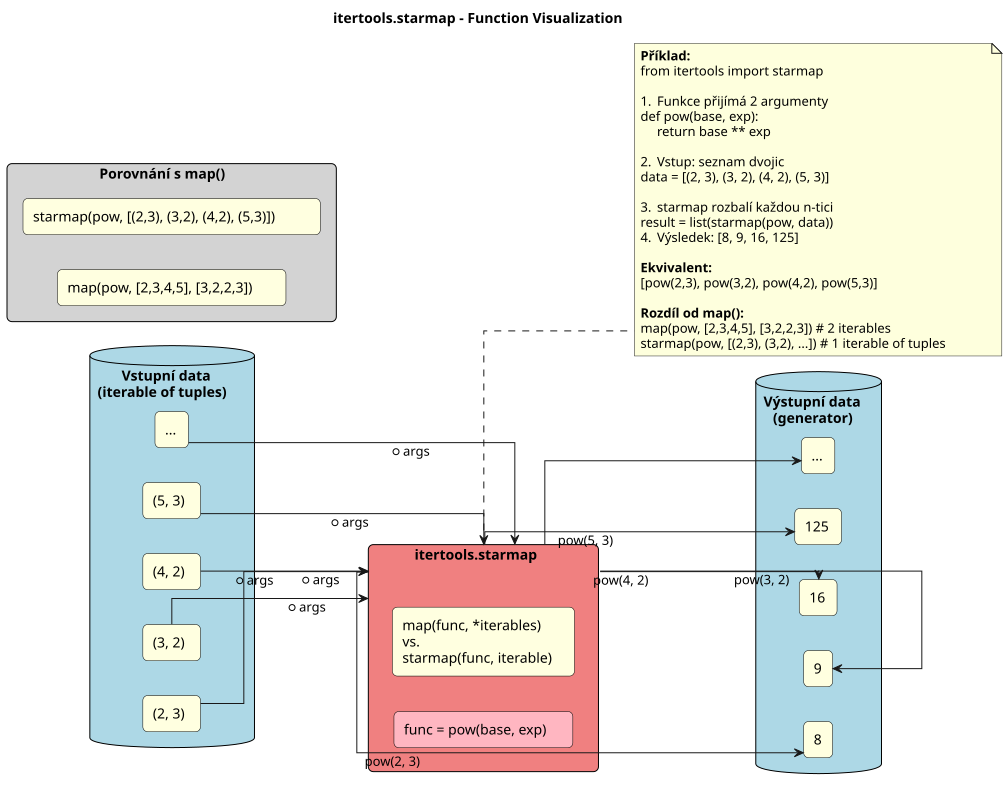

In [28]:
%%plantuml
@startuml
title itertools.starmap - Function Visualization
skinparam linetype ortho
skinparam shadowing false
left to right direction

' --- DEFINICE STYLŮ ---
skinparam rectangle {
    RoundCorner 10
    BackgroundColor LightYellow
    BorderColor Black
}
skinparam database {
    BackgroundColor LightBlue
    BorderColor Black
}
skinparam actor {
    BackgroundColor LightGreen
    BorderColor Black
}

' --- HLAVNÍ KOMPONENTY ---
rectangle "itertools.starmap" as starmap #LightCoral {
    rectangle "func = pow(base, exp)" as func #LightPink
    rectangle "map(func, *iterables)\nvs.\nstarmap(func, iterable)" as comparison #LightYellow
}

database "Vstupní data\n(iterable of tuples)" as input {
    rectangle "(2, 3)" as t1
    rectangle "(3, 2)" as t2
    rectangle "(4, 2)" as t3
    rectangle "(5, 3)" as t4
    rectangle "..." as dots
}

database "Výstupní data\n(generator)" as output {
    rectangle "8" as r1
    rectangle "9" as r2
    rectangle "16" as r3
    rectangle "125" as r4
    rectangle "..." as dots2
}

' --- VIZUALIZACE TOKU DAT ---
t1 -down-> starmap : "*args"
t2 -down-> starmap : "*args"
t3 -down-> starmap : "*args"
t4 -down-> starmap : "*args"
dots -down-> starmap : "*args"

starmap -down-> r1 : "pow(2, 3)"
starmap -down-> r2 : "pow(3, 2)"
starmap -down-> r3 : "pow(4, 2)"
starmap -down-> r4 : "pow(5, 3)"
starmap -down-> dots2

' --- PŘÍKLAD KÓDU ---
note right of starmap
  **Příklad:**
  from itertools import starmap
  
  # Funkce přijímá 2 argumenty
  def pow(base, exp):
      return base ** exp
  
  # Vstup: seznam dvojic
  data = [(2, 3), (3, 2), (4, 2), (5, 3)]
  
  # starmap rozbalí každou n-tici
  result = list(starmap(pow, data))
  # Výsledek: [8, 9, 16, 125]
  
  **Ekvivalent:**
  [pow(2,3), pow(3,2), pow(4,2), pow(5,3)]
  
  **Rozdíl od map():**
  map(pow, [2,3,4,5], [3,2,2,3])  # 2 iterables
  starmap(pow, [(2,3), (3,2), ...])  # 1 iterable of tuples
end note

' --- POROVNÁNÍ S MAP ---
rectangle "Porovnání s map()" as compare #LightGray {
    rectangle "map(pow, [2,3,4,5], [3,2,2,3])" as map_example
    rectangle "starmap(pow, [(2,3), (3,2), (4,2), (5,3)])" as starmap_example
}

@enduml

### tee(iterable, n=2)
Creates n independent iterators from a single iterable.

In [33]:
# Basic tee usage
original = [1, 2, 3, 4, 5]
iter1, iter2 = tee(original, 2)

print("First iterator:", list(iter1))
print("Second iterator:", list(iter2))

# Multiple independent iterations
numbers = range(5)
iters = tee(numbers, 3)

print("\nUsing multiple tee streams:")
print("  Stream A:", list(iters[0]))
print("  Stream B (squared):", [x**2 for x in iters[1]])
print("  Stream C (doubled):", [x*2 for x in iters[2]])

# Warning about memory usage
def demonstrate_tee_memory():
    large_data = range(1000000)
    
    # Without tee (must store in list if needed twice)
    data_list = list(large_data)
    list_size = sys.getsizeof(data_list) / 1024 / 1024
    
    # With tee (only stores differences)
    t1, t2 = tee(large_data, 2)
    tee_size = 0  # Hard to measure exact, but generally less for large data
    
    print(f"\nMemory comparison:")
    print(f"  List approach: ~{list_size:.1f} MB")
    print(f"  Tee approach:  Stores only the 'lookahead' buffer")

demonstrate_tee_memory()

First iterator: [1, 2, 3, 4, 5]
Second iterator: [1, 2, 3, 4, 5]

Using multiple tee streams:
  Stream A: [0, 1, 2, 3, 4]
  Stream B (squared): [0, 1, 4, 9, 16]
  Stream C (doubled): [0, 2, 4, 6, 8]

Memory comparison:
  List approach: ~7.6 MB
  Tee approach:  Stores only the 'lookahead' buffer


In [34]:
print(list(iter1))

[]


### zip_longest(*iterables, fillvalue=None)
Zips iterables, filling missing values.

In [ ]:
# Compare zip with zip_longest
names = ['Alice', 'Bob', 'Charlie', 'David']
scores = [85, 92, 78]

print("Regular zip (stops at shortest):")
for name, score in zip(names, scores):
    print(f"  {name}: {score}")

print("\nzip_longest (fills missing):")
for name, score in zip_longest(names, scores, fillvalue='N/A'):
    print(f"  {name}: {score}")

# Practical: align different length sequences
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
temperatures = [23, 25, 24, 26]  # Missing data
rainfall = [0, 5, 0, 2, 0, 1]    # Missing data

print("\nWeather data (aligned):")
for day, temp, rain in zip_longest(days, temperatures, rainfall, fillvalue='---'):
    print(f"  {day}: Temp={temp}°C, Rain={rain}mm")

## 3. Combinatoric Iterators

Generate permutations, combinations, and Cartesian products.

### product(*iterables, repeat=1)
Cartesian product of input iterables.

In [35]:
# Basic product
colors = ['red', 'blue']
sizes = ['S', 'M', 'L']

products = list(product(colors, sizes))
print("Product of colors and sizes:")
for color, size in products:
    print(f"  {color} - {size}")

# Product with repeat
digits = [1, 2, 3]
print("\nAll 2-digit combinations:")
for combo in product(digits, repeat=2):
    print(f"  {combo}")

# Practical: generate test cases
browsers = ['chrome', 'firefox', 'safari']
devices = ['desktop', 'mobile', 'tablet']
os_types = ['windows', 'macos', 'ios', 'android']

test_cases = list(product(browsers, devices, os_types))
print(f"\nTotal test cases: {len(test_cases)}")
print("First 5 test cases:")
for case in test_cases[:5]:
    print(f"  {case}")

# Dice roll combinations
dice_faces = range(1, 7)
print("\nAll possible dice roll combinations (2 dice):")
for roll in product(dice_faces, repeat=2):
    print(f"  {roll} = {sum(roll)}")

Product of colors and sizes:
  red - S
  red - M
  red - L
  blue - S
  blue - M
  blue - L

All 2-digit combinations:
  (1, 1)
  (1, 2)
  (1, 3)
  (2, 1)
  (2, 2)
  (2, 3)
  (3, 1)
  (3, 2)
  (3, 3)

Total test cases: 36
First 5 test cases:
  ('chrome', 'desktop', 'windows')
  ('chrome', 'desktop', 'macos')
  ('chrome', 'desktop', 'ios')
  ('chrome', 'desktop', 'android')
  ('chrome', 'mobile', 'windows')

All possible dice roll combinations (2 dice):
  (1, 1) = 2
  (1, 2) = 3
  (1, 3) = 4
  (1, 4) = 5
  (1, 5) = 6
  (1, 6) = 7
  (2, 1) = 3
  (2, 2) = 4
  (2, 3) = 5
  (2, 4) = 6
  (2, 5) = 7
  (2, 6) = 8
  (3, 1) = 4
  (3, 2) = 5
  (3, 3) = 6
  (3, 4) = 7
  (3, 5) = 8
  (3, 6) = 9
  (4, 1) = 5
  (4, 2) = 6
  (4, 3) = 7
  (4, 4) = 8
  (4, 5) = 9
  (4, 6) = 10
  (5, 1) = 6
  (5, 2) = 7
  (5, 3) = 8
  (5, 4) = 9
  (5, 5) = 10
  (5, 6) = 11
  (6, 1) = 7
  (6, 2) = 8
  (6, 3) = 9
  (6, 4) = 10
  (6, 5) = 11
  (6, 6) = 12


### permutations(iterable, r=None)
All possible ordered arrangements.

In [36]:
# Basic permutations
items = ['A', 'B', 'C']

print("All permutations of length 2:")
for perm in permutations(items, 2):
    print(f"  {perm}")

print("\nAll permutations of length 3:")
for perm in permutations(items, 3):
    print(f"  {perm}")

# Practical: race results
runners = ['Alice', 'Bob', 'Charlie', 'Diana']
print("\nPossible top 3 finishes:")
for i, podium in enumerate(permutations(runners, 3), 1):
    print(f"  {i:2d}. Gold: {podium[0]}, Silver: {podium[1]}, Bronze: {podium[2]}")

# Password brute-force simulation
chars = ['a', 'b', '1', '2']
print("\nPossible 3-character passwords:")
for password in permutations(chars, 3):
    print(f"  {''.join(password)}")

All permutations of length 2:
  ('A', 'B')
  ('A', 'C')
  ('B', 'A')
  ('B', 'C')
  ('C', 'A')
  ('C', 'B')

All permutations of length 3:
  ('A', 'B', 'C')
  ('A', 'C', 'B')
  ('B', 'A', 'C')
  ('B', 'C', 'A')
  ('C', 'A', 'B')
  ('C', 'B', 'A')

Possible top 3 finishes:
   1. Gold: Alice, Silver: Bob, Bronze: Charlie
   2. Gold: Alice, Silver: Bob, Bronze: Diana
   3. Gold: Alice, Silver: Charlie, Bronze: Bob
   4. Gold: Alice, Silver: Charlie, Bronze: Diana
   5. Gold: Alice, Silver: Diana, Bronze: Bob
   6. Gold: Alice, Silver: Diana, Bronze: Charlie
   7. Gold: Bob, Silver: Alice, Bronze: Charlie
   8. Gold: Bob, Silver: Alice, Bronze: Diana
   9. Gold: Bob, Silver: Charlie, Bronze: Alice
  10. Gold: Bob, Silver: Charlie, Bronze: Diana
  11. Gold: Bob, Silver: Diana, Bronze: Alice
  12. Gold: Bob, Silver: Diana, Bronze: Charlie
  13. Gold: Charlie, Silver: Alice, Bronze: Bob
  14. Gold: Charlie, Silver: Alice, Bronze: Diana
  15. Gold: Charlie, Silver: Bob, Bronze: Alice
  16. Gol

### combinations(iterable, r)
All possible unordered selections without repetition.

In [37]:
# Basic combinations
items = ['A', 'B', 'C', 'D']

print("All combinations of length 2:")
for combo in combinations(items, 2):
    print(f"  {combo}")

print("\nAll combinations of length 3:")
for combo in combinations(items, 3):
    print(f"  {combo}")

# Practical: lottery numbers
numbers = range(1, 10)  # 1-9
print("\nPossible lottery picks (3 numbers from 1-9):")
for pick in combinations(numbers, 3):
    print(f"  {pick}")

# Team selection
players = ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve']
print("\nPossible 3-person teams:")
for team in combinations(players, 3):
    print(f"  Team: {', '.join(team)}")

All combinations of length 2:
  ('A', 'B')
  ('A', 'C')
  ('A', 'D')
  ('B', 'C')
  ('B', 'D')
  ('C', 'D')

All combinations of length 3:
  ('A', 'B', 'C')
  ('A', 'B', 'D')
  ('A', 'C', 'D')
  ('B', 'C', 'D')

Possible lottery picks (3 numbers from 1-9):
  (1, 2, 3)
  (1, 2, 4)
  (1, 2, 5)
  (1, 2, 6)
  (1, 2, 7)
  (1, 2, 8)
  (1, 2, 9)
  (1, 3, 4)
  (1, 3, 5)
  (1, 3, 6)
  (1, 3, 7)
  (1, 3, 8)
  (1, 3, 9)
  (1, 4, 5)
  (1, 4, 6)
  (1, 4, 7)
  (1, 4, 8)
  (1, 4, 9)
  (1, 5, 6)
  (1, 5, 7)
  (1, 5, 8)
  (1, 5, 9)
  (1, 6, 7)
  (1, 6, 8)
  (1, 6, 9)
  (1, 7, 8)
  (1, 7, 9)
  (1, 8, 9)
  (2, 3, 4)
  (2, 3, 5)
  (2, 3, 6)
  (2, 3, 7)
  (2, 3, 8)
  (2, 3, 9)
  (2, 4, 5)
  (2, 4, 6)
  (2, 4, 7)
  (2, 4, 8)
  (2, 4, 9)
  (2, 5, 6)
  (2, 5, 7)
  (2, 5, 8)
  (2, 5, 9)
  (2, 6, 7)
  (2, 6, 8)
  (2, 6, 9)
  (2, 7, 8)
  (2, 7, 9)
  (2, 8, 9)
  (3, 4, 5)
  (3, 4, 6)
  (3, 4, 7)
  (3, 4, 8)
  (3, 4, 9)
  (3, 5, 6)
  (3, 5, 7)
  (3, 5, 8)
  (3, 5, 9)
  (3, 6, 7)
  (3, 6, 8)
  (3, 6, 9)
  (3, 7, 8)

### combinations_with_replacement(iterable, r)
Combinations where elements can be repeated.

In [38]:
# Compare combinations vs combinations_with_replacement
items = ['A', 'B', 'C']
r = 2

print("Combinations (no replacement):")
for combo in combinations(items, r):
    print(f"  {combo}")

print("\nCombinations with replacement:")
for combo in combinations_with_replacement(items, r):
    print(f"  {combo}")

# Practical: ice cream scoops
flavors = ['Vanilla', 'Chocolate', 'Strawberry']
print("\nPossible 3-scoop combinations (with repeats allowed):")
for combo in combinations_with_replacement(flavors, 3):
    print(f"  {', '.join(combo)}")

# Change combinations
coins = [1, 5, 10, 25]  # pennies, nickels, dimes, quarters
print("\nWays to make change (using 3 coins, repeats allowed):")
for combo in combinations_with_replacement(coins, 3):
    print(f"  {combo} = {sum(combo)}¢")

Combinations (no replacement):
  ('A', 'B')
  ('A', 'C')
  ('B', 'C')

Combinations with replacement:
  ('A', 'A')
  ('A', 'B')
  ('A', 'C')
  ('B', 'B')
  ('B', 'C')
  ('C', 'C')

Possible 3-scoop combinations (with repeats allowed):
  Vanilla, Vanilla, Vanilla
  Vanilla, Vanilla, Chocolate
  Vanilla, Vanilla, Strawberry
  Vanilla, Chocolate, Chocolate
  Vanilla, Chocolate, Strawberry
  Vanilla, Strawberry, Strawberry
  Chocolate, Chocolate, Chocolate
  Chocolate, Chocolate, Strawberry
  Chocolate, Strawberry, Strawberry
  Strawberry, Strawberry, Strawberry

Ways to make change (using 3 coins, repeats allowed):
  (1, 1, 1) = 3¢
  (1, 1, 5) = 7¢
  (1, 1, 10) = 12¢
  (1, 1, 25) = 27¢
  (1, 5, 5) = 11¢
  (1, 5, 10) = 16¢
  (1, 5, 25) = 31¢
  (1, 10, 10) = 21¢
  (1, 10, 25) = 36¢
  (1, 25, 25) = 51¢
  (5, 5, 5) = 15¢
  (5, 5, 10) = 20¢
  (5, 5, 25) = 35¢
  (5, 10, 10) = 25¢
  (5, 10, 25) = 40¢
  (5, 25, 25) = 55¢
  (10, 10, 10) = 30¢
  (10, 10, 25) = 45¢
  (10, 25, 25) = 60¢
  (25, 25, 25

## 4. Practical Applications

Real-world examples combining multiple itertools functions.

### Data Processing Pipeline
Process large datasets efficiently without loading everything into memory.

In [39]:
def process_sales_data():
    """Simulate processing a large sales dataset"""
    # Generate sample data (in reality, this would read from a file)
    def generate_sales():
        products = ['Laptop', 'Phone', 'Tablet', 'Monitor']
        regions = ['North', 'South', 'East', 'West']
        
        for i in range(100):
            yield {
                'id': i,
                'product': products[i % 4],
                'region': regions[i % 4],
                'amount': (i * 100) % 500 + 100,
                'date': f'2024-{(i%12)+1:02d}-{(i%28)+1:02d}'
            }
    
    # Create multiple iterators for different analyses
    data_stream = generate_sales()
    iter1, iter2, iter3 = tee(data_stream, 3)
    
    # Analysis 1: Calculate running totals by product
    def analyze_by_product(data):
        sorted_data = sorted(data, key=lambda x: x['product'])
        for product, group in groupby(sorted_data, key=lambda x: x['product']):
            amounts = [sale['amount'] for sale in group]
            running_total = list(accumulate(amounts))
            yield product, running_total[-1] if running_total else 0
    
    # Analysis 2: Find high-value sales
    high_value = filterfalse(lambda x: x['amount'] < 300, iter2)
    
    # Analysis 3: Monthly sales trends
    def monthly_trends(data):
        # Extract month from date
        def get_month(sale):
            return sale['date'][5:7]
        
        sorted_by_month = sorted(data, key=get_month)
        for month, group in groupby(sorted_by_month, key=get_month):
            amounts = [sale['amount'] for sale in group]
            yield month, sum(amounts) / len(amounts)
    
    print("Sales Analysis Results:")
    print("\nTotal by product:")
    for product, total in analyze_by_product(list(iter1)):
        print(f"  {product}: ${total}")
    
    print("\nHigh-value sales (first 5):")
    for sale in islice(high_value, 5):
        print(f"  {sale['product']}: ${sale['amount']}")
    
    print("\nMonthly average sales:")
    for month, avg in monthly_trends(list(iter3)):
        print(f"  Month {month}: ${avg:.2f}")

process_sales_data()

Sales Analysis Results:

Total by product:
  Laptop: $7500
  Monitor: $7500
  Phone: $7500
  Tablet: $7500

High-value sales (first 5):
  Tablet: $300
  Monitor: $400
  Laptop: $500
  Monitor: $300
  Laptop: $400

Monthly average sales:
  Month 01: $288.89
  Month 02: $277.78
  Month 03: $322.22
  Month 04: $311.11
  Month 05: $325.00
  Month 06: $300.00
  Month 07: $275.00
  Month 08: $312.50
  Month 09: $287.50
  Month 10: $325.00
  Month 11: $300.00
  Month 12: $275.00


### Sliding Window Operations
Common in time series analysis and signal processing.

In [40]:
def sliding_window(iterable, n):
    """Create sliding windows of size n"""
    iters = tee(iterable, n)
    for i, it in enumerate(iters):
        # Skip i elements for each iterator
        next(islice(it, i, i), None)
    return zip(*iters)

# Example: moving average
stock_prices = [100, 102, 101, 103, 105, 104, 106, 108, 107, 109]

print("Moving averages (window size 3):")
for window in sliding_window(stock_prices, 3):
    avg = sum(window) / len(window)
    print(f"  Window {window} -> {avg:.2f}")

# Detect patterns
def detect_patterns(prices):
    windows = sliding_window(prices, 3)
    
    for w in windows:
        if w[0] < w[1] > w[2]:
            pattern = "Peak"
        elif w[0] > w[1] < w[2]:
            pattern = "Valley"
        elif all(w[i] < w[i+1] for i in range(len(w)-1)):
            pattern = "Up trend"
        elif all(w[i] > w[i+1] for i in range(len(w)-1)):
            pattern = "Down trend"
        else:
            pattern = "No pattern"
        
        yield w, pattern

print("\nPrice pattern detection:")
for window, pattern in detect_patterns(stock_prices):
    print(f"  {window}: {pattern}")

Moving averages (window size 3):
  Window (100, 102, 101) -> 101.00
  Window (102, 101, 103) -> 102.00
  Window (101, 103, 105) -> 103.00
  Window (103, 105, 104) -> 104.00
  Window (105, 104, 106) -> 105.00
  Window (104, 106, 108) -> 106.00
  Window (106, 108, 107) -> 107.00
  Window (108, 107, 109) -> 108.00

Price pattern detection:
  (100, 102, 101): Peak
  (102, 101, 103): Valley
  (101, 103, 105): Up trend
  (103, 105, 104): Peak
  (105, 104, 106): Valley
  (104, 106, 108): Up trend
  (106, 108, 107): Peak
  (108, 107, 109): Valley


### Efficient Cartesian Products in Analytics
Generate all combinations for A/B testing and experimental design.

In [41]:
# A/B test design
def design_experiment():
    factors = {
        'price': [9.99, 14.99, 19.99],
        'discount': [0, 10, 20],  # percentage
        'placement': ['top', 'middle', 'bottom'],
        'color': ['red', 'blue', 'green']
    }
    
    # Generate all combinations
    experiments = product(*factors.values())
    
    print("A/B Test Design:")
    print(f"Total test combinations: {len(list(product(*factors.values())))} (calculated)")
    
    # Show sample of experiments
    print("\nSample experiments (first 10):")
    for i, exp in enumerate(islice(product(*factors.values()), 10)):
        conditions = dict(zip(factors.keys(), exp))
        print(f"  Experiment {i+1}:")
        for factor, value in conditions.items():
            print(f"    {factor}: {value}")

design_experiment()

# Fractional factorial design (using islice to sample)
def fractional_factorial(factors, fraction=0.1):
    """Take a random sample of all combinations"""
    total = len(list(product(*factors.values())))
    sample_size = int(total * fraction)
    
    # Use islice to get subset
    all_combos = product(*factors.values())
    sampled = islice(all_combos, 0, sample_size)
    
    return list(sampled)

print("\nFractional factorial design (10% sample):")
sample = fractional_factorial(factors, 0.1)
print(f"Sampled {len(sample)} combinations")

A/B Test Design:
Total test combinations: 81 (calculated)

Sample experiments (first 10):
  Experiment 1:
    price: 9.99
    discount: 0
    placement: top
    color: red
  Experiment 2:
    price: 9.99
    discount: 0
    placement: top
    color: blue
  Experiment 3:
    price: 9.99
    discount: 0
    placement: top
    color: green
  Experiment 4:
    price: 9.99
    discount: 0
    placement: middle
    color: red
  Experiment 5:
    price: 9.99
    discount: 0
    placement: middle
    color: blue
  Experiment 6:
    price: 9.99
    discount: 0
    placement: middle
    color: green
  Experiment 7:
    price: 9.99
    discount: 0
    placement: bottom
    color: red
  Experiment 8:
    price: 9.99
    discount: 0
    placement: bottom
    color: blue
  Experiment 9:
    price: 9.99
    discount: 0
    placement: bottom
    color: green
  Experiment 10:
    price: 9.99
    discount: 10
    placement: top
    color: red

Fractional factorial design (10% sample):


NameError: name 'factors' is not defined

### Memory-Efficient Data Streaming
Process large files line by line without loading entire file.

In [42]:
# Simulate processing a large log file
def simulate_log_file():
    """Generator that simulates a large log file"""
    log_levels = cycle(['INFO', 'DEBUG', 'WARNING', 'ERROR'])
    messages = cycle([
        'User logged in',
        'Database query executed',
        'Cache miss',
        'Connection timeout',
        'File not found'
    ])
    
    for i in count(1):
        if i > 1000:  # Simulate 1000 log entries
            break
        yield f"{i:04d} [{next(log_levels)}] {next(messages)}"

def process_large_log():
    """Process log file efficiently"""
    log_stream = simulate_log_file()
    
    # Create multiple streams for different analyses
    stream1, stream2, stream3 = tee(log_stream, 3)
    
    # Analysis 1: Count log levels
    def count_levels(stream):
        # Extract log level from each line
        levels = (line.split('[')[1].split(']')[0] for line in stream)
        sorted_levels = sorted(levels)
        
        for level, group in groupby(sorted_levels):
            yield level, len(list(group))
    
    # Analysis 2: Find errors
    errors = filter(lambda x: 'ERROR' in x, stream2)
    
    # Analysis 3: Sample every 10th line
    sampled = islice(stream3, 0, None, 10)
    
    print("Log Analysis Results:")
    print("\nLog level counts:")
    for level, count in count_levels(stream1):
        print(f"  {level}: {count}")
    
    print("\nFirst 5 errors:")
    for error in islice(errors, 5):
        print(f"  {error}")
    
    print("\nSampled log entries (every 10th):")
    for entry in islice(sampled, 5):
        print(f"  {entry}")

process_large_log()

Log Analysis Results:

Log level counts:
  DEBUG: 250
  ERROR: 250
  INFO: 250

First 5 errors:
  0004 [ERROR] Connection timeout
  0008 [ERROR] Cache miss
  0012 [ERROR] Database query executed
  0016 [ERROR] User logged in
  0020 [ERROR] File not found

Sampled log entries (every 10th):
  0001 [INFO] User logged in
  0011 [WARNING] User logged in
  0021 [INFO] User logged in
  0031 [WARNING] User logged in
  0041 [INFO] User logged in


## Performance Comparison
Compare itertools approaches with traditional methods.

In [43]:
import timeit

def performance_comparison():
    """Compare performance of different approaches"""
    
    # Test 1: Chaining iterables
    lists = [list(range(1000)) for _ in range(10)]
    
    def traditional_chain():
        result = []
        for lst in lists:
            result.extend(lst)
        return result
    
    def itertools_chain():
        return list(chain.from_iterable(lists))
    
    # Test 2: Combinations
    items = list(range(20))
    
    def traditional_combinations():
        result = []
        n = len(items)
        for i in range(n):
            for j in range(i+1, n):
                result.append((items[i], items[j]))
        return result
    
    def itertools_combinations():
        return list(combinations(items, 2))
    
    # Run benchmarks
    print("Performance Comparison:")
    
    chain_time_trad = timeit.timeit(traditional_chain, number=1000)
    chain_time_it = timeit.timeit(itertools_chain, number=1000)
    print(f"\nChaining (1000 runs):")
    print(f"  Traditional: {chain_time_trad:.4f} seconds")
    print(f"  Itertools:   {chain_time_it:.4f} seconds")
    print(f"  Speedup:     {chain_time_trad/chain_time_it:.2f}x")
    
    combo_time_trad = timeit.timeit(traditional_combinations, number=1000)
    combo_time_it = timeit.timeit(itertools_combinations, number=1000)
    print(f"\nCombinations (1000 runs):")
    print(f"  Traditional: {combo_time_trad:.4f} seconds")
    print(f"  Itertools:   {combo_time_it:.4f} seconds")
    print(f"  Speedup:     {combo_time_trad/combo_time_it:.2f}x")

performance_comparison()

Performance Comparison:

Chaining (1000 runs):
  Traditional: 0.0451 seconds
  Itertools:   0.0757 seconds
  Speedup:     0.60x

Combinations (1000 runs):
  Traditional: 0.0128 seconds
  Itertools:   0.0064 seconds
  Speedup:     1.99x


## Summary and Best Practices

### When to Use itertools
1. **Memory efficiency**: When working with large datasets
2. **Code clarity**: Functional programming style
3. **Performance**: Optimized C implementation
4. **Combinatorics**: Generating permutations/combinations

### Key Takeaways
- Iterators are lazy - they generate values on-demand
- Combine itertools functions for powerful data pipelines
- Use `tee()` carefully - it can use memory for lookahead
- Sort data before using `groupby()`
- Infinite iterators need stopping conditions

### Common Pitfalls
1. **Modifying data while iterating**
2. **Forgetting to sort for groupby**
3. **Using tee on large iterators without considering memory**
4. **Not handling StopIteration**
5. **Creating unnecessary lists**

In [3]:
# Quick reference function
def itertools_quick_reference():
    """Print a quick reference table"""
    
    reference = {
        'Function': ['count()', 'cycle()', 'repeat()', 'accumulate()', 
                    'chain()', 'compress()', 'dropwhile()', 'groupby()',
                    'islice()', 'pairwise()', 'starmap()', 'tee()',
                    'zip_longest()', 'product()', 'permutations()',
                    'combinations()', 'combinations_with_replacement()'],
        'Category': ['Infinite'] * 3 + ['Finite'] * 10 + ['Combinatoric'] * 4,
        'Description': [
            'Count from start with step',
            'Cycle through iterable',
            'Repeat object',
            'Accumulate results',
            'Chain iterables',
            'Filter with selectors',
            'Drop while predicate true',
            'Group consecutive elements',
            'Slice iterator',
            'Get overlapping pairs',
            'Map with unpacked args',
            'Create independent iterators',
            'Zip with fill values',
            'Cartesian product',
            'Ordered arrangements',
            'Unordered selections',
            'Selections with repetition'
        ]
    }
    
    df = pd.DataFrame(reference)
    display(df)

itertools_quick_reference()

,Function,Category,Description
0,count(),Infinite,Count from start with step
1,cycle(),Infinite,Cycle through iterable
2,repeat(),Infinite,Repeat object
3,accumulate(),Finite,Accumulate results
4,chain(),Finite,Chain iterables
5,compress(),Finite,Filter with selectors
6,dropwhile(),Finite,Drop while predicate true
7,groupby(),Finite,Group consecutive elements
8,islice(),Finite,Slice iterator
9,pairwise(),Finite,Get overlapping pairs


## Exercises

Try these exercises to test your understanding:

1. **Chunking**: Write a function that splits an iterable into chunks of size n
2. **Running average**: Calculate running average using accumulate
3. **Nested loops flattening**: Replace nested loops with product()
4. **Data deduplication**: Remove consecutive duplicates using groupby
5. **Round-robin**: Implement round-robin merging of multiple iterables

In [44]:
# Exercise solutions (uncomment to run)

# 1. Chunking
def chunked(iterable, n):
    """Split iterable into chunks of size n"""
    it = iter(iterable)
    while True:
        chunk = list(islice(it, n))
        if not chunk:
            break
        yield chunk

print("Chunked result:")
for chunk in chunked(range(10), 3):
    print(f"  {chunk}")

# 2. Running average
def running_average(iterable):
    """Calculate running average"""
    total = 0
    for i, x in enumerate(iterable, 1):
        total += x
        yield total / i

print("\nRunning average:")
print(f"  {list(running_average([10, 20, 30, 40, 50]))}")

# 3. Remove consecutive duplicates
def unique_justseen(iterable):
    """Remove consecutive duplicates"""
    return (key for key, group in groupby(iterable))

data = [1, 1, 2, 2, 2, 3, 1, 1, 4, 4]
print("\nRemove consecutive duplicates:")
print(f"  Original: {data}")
print(f"  Unique:   {list(unique_justseen(data))}")

Chunked result:
  [0, 1, 2]
  [3, 4, 5]
  [6, 7, 8]
  [9]

Running average:
  [10.0, 15.0, 20.0, 25.0, 30.0]

Remove consecutive duplicates:
  Original: [1, 1, 2, 2, 2, 3, 1, 1, 4, 4]
  Unique:   [1, 2, 3, 1, 4]


# This comprehensive Jupyter notebook covers:

## Key Features:
- **Complete Theory:** Each function includes explanations and use cases

- **Practical Examples:** Real-world applications for each function

- **Code Demonstrations:** Runable code with output examples

- **Performance Comparisons:** Shows why itertools is efficient

- **Best Practices:** Common pitfalls and how to avoid them

- **Exercises:** Practice problems with solutions

## The notebook is organized into sections:
- **Infinite Iterators:** *count(), cycle(), repeat()*

- **Finite Iterators:** *accumulate(), chain(), compress(), dropwhile(), filterfalse(), groupby(), islice(), pairwise(), starmap(), takewhile(), tee(), zip_longest()*

- **Combinatoric Iterators:** *product(), permutations(), combinations(), combinations_with_replacement()*

- **Practical Applications:** Data pipelines, sliding windows, A/B testing, streaming

- **Performance Comparison:** Benchmarks vs traditional methods

- **Quick Reference:** Summary table of all functions